<a href="https://colab.research.google.com/github/Evidence11710/Evi-links-/blob/main/Retrieving_Weights_and_Bias_Using_a_Simple_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Input data shape: (2000, 3)
Target data shape: (2000,)

First five input samples:
[[ 0.49671414 -0.1382643   0.64768857]
 [ 1.5230298  -0.23415338 -0.23413695]
 [ 1.5792128   0.7674347  -0.46947438]
 [ 0.54256004 -0.46341768 -0.46572974]
 [ 0.24196227 -1.9132802  -1.7249179 ]]

First five target values:
[-0.06648985  0.11010928  0.60111326 -0.32099375 -1.2586848 ]

Training input shape: (1600, 3)
Training target shape: (1600,)
Testing input shape: (400, 3)
Testing target shape: (400,)

Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ linear_output (Dense)           │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)


Model training completed successfully.

Test Mean Squared Error: 0.0002454089990351349
Test Mean Absolute Error: 0.01276398915797472

--------------------------------------
TRUE AND LEARNED MODEL PARAMETERS
--------------------------------------

True weights:
[0.3 0.5 0.1]

Learned weights:
[0.29782817 0.4976191  0.09560326]

True bias:
-0.2

Learned bias:
-0.20992987

Weight comparison:
Feature 1: True weight = 0.3000, Learned weight = 0.2978
Feature 2: True weight = 0.5000, Learned weight = 0.4976
Feature 3: True weight = 0.1000, Learned weight = 0.0956

Bias: True bias = -0.2000, Learned bias = -0.2099

First 10 actual and predicted values:
Actual value: -0.8353 | Predicted value: -0.8514
Actual value: -0.0453 | Predicted value: -0.0440
Actual value: 0.3011 | Predicted value: 0.2856
Actual value: -0.0217 | Predicted value: -0.0288
Actual value: -0.0293 | Predicted value: -0.0489
Actual value: 0.7112 | Predicted value: 0.6830
Actual value: -0.3743 | Predicted value: -0.3946
Actual 

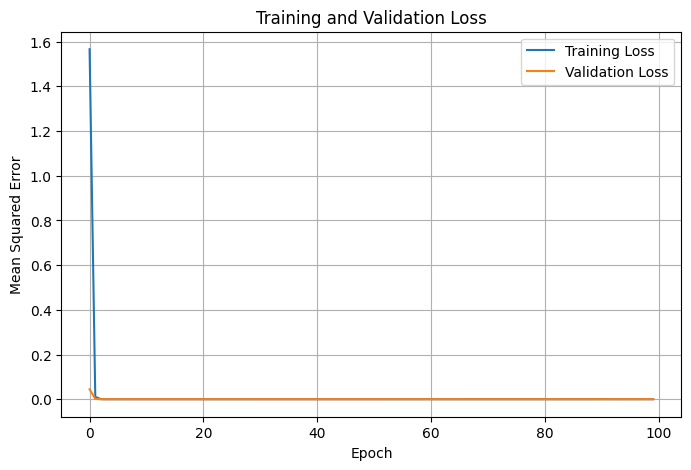

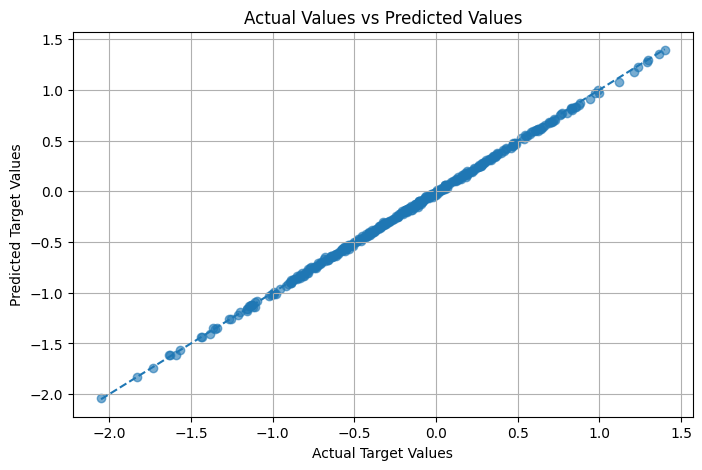


CONCLUSION:
The neural network successfully learned the relationship between the three input features and the target variable.
The recovered weights are close to the true weights [0.3, 0.5, 0.1], and the recovered bias is close to -0.2.
Small differences between the true and learned parameters are expected because Gaussian noise was added to the dataset.


In [1]:
# DEEP LEARNING IN PRACTICE – ASSIGNMENT I

# Name: Evidence Chinonso Nwauzor

# Import required libraries

import numpy as np

import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow import keras

from tensorflow.keras import layers

# Set random seeds so the results can be reproduced

np.random.seed(42)

tf.random.set_seed(42)

# -----------------------------------------------------

# 1. Generate synthetic data

# -----------------------------------------------------

# Number of samples and input features

num_samples = 2000

num_features = 3

# Generate 2,000 samples with 3 features

x = np.random.randn(num_samples, num_features).astype(np.float32)

# True weights and bias given in the assignment

true_weights = np.array([0.3, 0.5, 0.1], dtype=np.float32)

true_bias = -0.2

# Generate Gaussian noise

noise = np.random.normal(

    loc=0.0,

    scale=0.01,

    size=num_samples

).astype(np.float32)

# Calculate the target values

# y = x1(0.3) + x2(0.5) + x3(0.1) - 0.2 + noise

y = np.dot(x, true_weights) + true_bias + noise

# Display the shapes of the generated data

print("Input data shape:", x.shape)

print("Target data shape:", y.shape)

print("\nFirst five input samples:")

print(x[:5])

print("\nFirst five target values:")

print(y[:5])

# -----------------------------------------------------

# 2. Split the data into training and testing sets

# -----------------------------------------------------

# Shuffle the data

indices = np.random.permutation(num_samples)

x = x[indices]

y = y[indices]

# Use 80% for training and 20% for testing

split_index = int(0.8 * num_samples)

x_train = x[:split_index]

y_train = y[:split_index]

x_test = x[split_index:]

y_test = y[split_index:]

print("\nTraining input shape:", x_train.shape)

print("Training target shape:", y_train.shape)

print("Testing input shape:", x_test.shape)

print("Testing target shape:", y_test.shape)

# -----------------------------------------------------

# 3. Build the deep learning model

# -----------------------------------------------------

model = keras.Sequential([

    keras.Input(shape=(3,)),

    layers.Dense(

        units=1,

        activation=None,

        name="linear_output"

    )

])

# Compile the model

model.compile(

    optimizer=keras.optimizers.Adam(learning_rate=0.05),

    loss="mean_squared_error",

    metrics=["mean_absolute_error"]

)

# Display the model structure

print("\nModel Summary:")

model.summary()

# -----------------------------------------------------

# 4. Train the model

# -----------------------------------------------------

history = model.fit(

    x_train,

    y_train,

    epochs=100,

    batch_size=32,

    validation_split=0.2,

    verbose=0

)

print("\nModel training completed successfully.")

# -----------------------------------------------------

# 5. Evaluate the model

# -----------------------------------------------------

test_loss, test_mae = model.evaluate(

    x_test,

    y_test,

    verbose=0

)

print("\nTest Mean Squared Error:", test_loss)

print("Test Mean Absolute Error:", test_mae)

# -----------------------------------------------------

# 6. Retrieve the learned weights and bias

# -----------------------------------------------------

learned_weights, learned_bias = model.layers[0].get_weights()

learned_weights = learned_weights.flatten()

learned_bias = learned_bias[0]

print("\n--------------------------------------")

print("TRUE AND LEARNED MODEL PARAMETERS")

print("--------------------------------------")

print("\nTrue weights:")

print(true_weights)

print("\nLearned weights:")

print(learned_weights)

print("\nTrue bias:")

print(true_bias)

print("\nLearned bias:")

print(learned_bias)

# Display individual weights

print("\nWeight comparison:")

for i in range(num_features):

    print(

        f"Feature {i + 1}: "

        f"True weight = {true_weights[i]:.4f}, "

        f"Learned weight = {learned_weights[i]:.4f}"

    )

print(

    f"\nBias: True bias = {true_bias:.4f}, "

    f"Learned bias = {learned_bias:.4f}"

)

# -----------------------------------------------------

# 7. Make predictions

# -----------------------------------------------------

predictions = model.predict(x_test, verbose=0).flatten()

print("\nFirst 10 actual and predicted values:")

for i in range(10):

    print(

        f"Actual value: {y_test[i]:.4f} | "

        f"Predicted value: {predictions[i]:.4f}"

    )

# -----------------------------------------------------

# 8. Plot training and validation loss

# -----------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(

    history.history["loss"],

    label="Training Loss"

)

plt.plot(

    history.history["val_loss"],

    label="Validation Loss"

)

plt.title("Training and Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Mean Squared Error")

plt.legend()

plt.grid(True)

plt.show()

# -----------------------------------------------------

# 9. Plot actual values against predicted values

# -----------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(

    y_test,

    predictions,

    alpha=0.6

)

minimum_value = min(y_test.min(), predictions.min())

maximum_value = max(y_test.max(), predictions.max())

plt.plot(

    [minimum_value, maximum_value],

    [minimum_value, maximum_value],

    linestyle="--"

)

plt.title("Actual Values vs Predicted Values")

plt.xlabel("Actual Target Values")

plt.ylabel("Predicted Target Values")

plt.grid(True)

plt.show()

# -----------------------------------------------------

# 10. Final conclusion

# -----------------------------------------------------

print("\nCONCLUSION:")

print(

    "The neural network successfully learned the relationship "

    "between the three input features and the target variable."

)

print(

    "The recovered weights are close to the true weights "

    "[0.3, 0.5, 0.1], and the recovered bias is close to -0.2."

)

print(

    "Small differences between the true and learned parameters "

    "are expected because Gaussian noise was added to the dataset."

)